In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

GAMES = ["dungeon", "doom", "zelda", "pokemon", "sokoban"]

# reward 체계 (5개)
REWARDS = [
    (1, "region",             "condition_0"),
    (2, "path_length",        "condition_1"),
    (3, "interactable_count", "condition_2"),
    (4, "hazard_count",       "condition_3"),
    (5, "collectable_count",  "condition_4"),
]

# ── ann.json 로드 ─────────────────────────────────────────────────────────────
# 캐시 디렉토리: annotation_figure.ipynb → reward_annotations/ → multigame/cache/artifacts/
_HERE = Path().resolve()  # notebook 실행 디렉토리 (dataset/reward_annotations/)
CACHE_DIR = _HERE.parent / "multigame" / "cache" / "artifacts"

def _load_ann_json(cache_dir: Path, game: str) -> list:
    """게임 캐시 디렉토리에서 ann.json을 찾아 annotations 리스트를 반환한다."""
    game_dir = cache_dir / game
    if not game_dir.exists():
        return []
    ann_files = sorted(game_dir.glob("*.ann.json"))
    if not ann_files:
        return []
    data = json.loads(ann_files[-1].read_text(encoding="utf-8"))
    rows = data.get("annotations", [])
    for r in rows:
        r["game"] = game  # game 컬럼 추가
    return rows

dfs = {}
for game in GAMES:
    rows = _load_ann_json(CACHE_DIR, game)
    if rows:
        dfs[game] = pd.DataFrame(rows)
    else:
        print(f"[WARNING] {game}: ann.json 없음 (annotate.py를 먼저 실행하세요)")

all_df = pd.concat(dfs.values(), ignore_index=True) if dfs else pd.DataFrame()
print(f"전체 rows: {len(all_df)}")
if len(all_df) > 0:
    all_df.groupby(["game", "feature_name"]).size().unstack(fill_value=0)

전체 rows: 40000


|## Boxplot — reward별로 묶기, 각 게임 분포 비교

## Lineplot — reward별로 묶기, 게임별 KDE 분포 (같은 reward는 y-scale 통일)

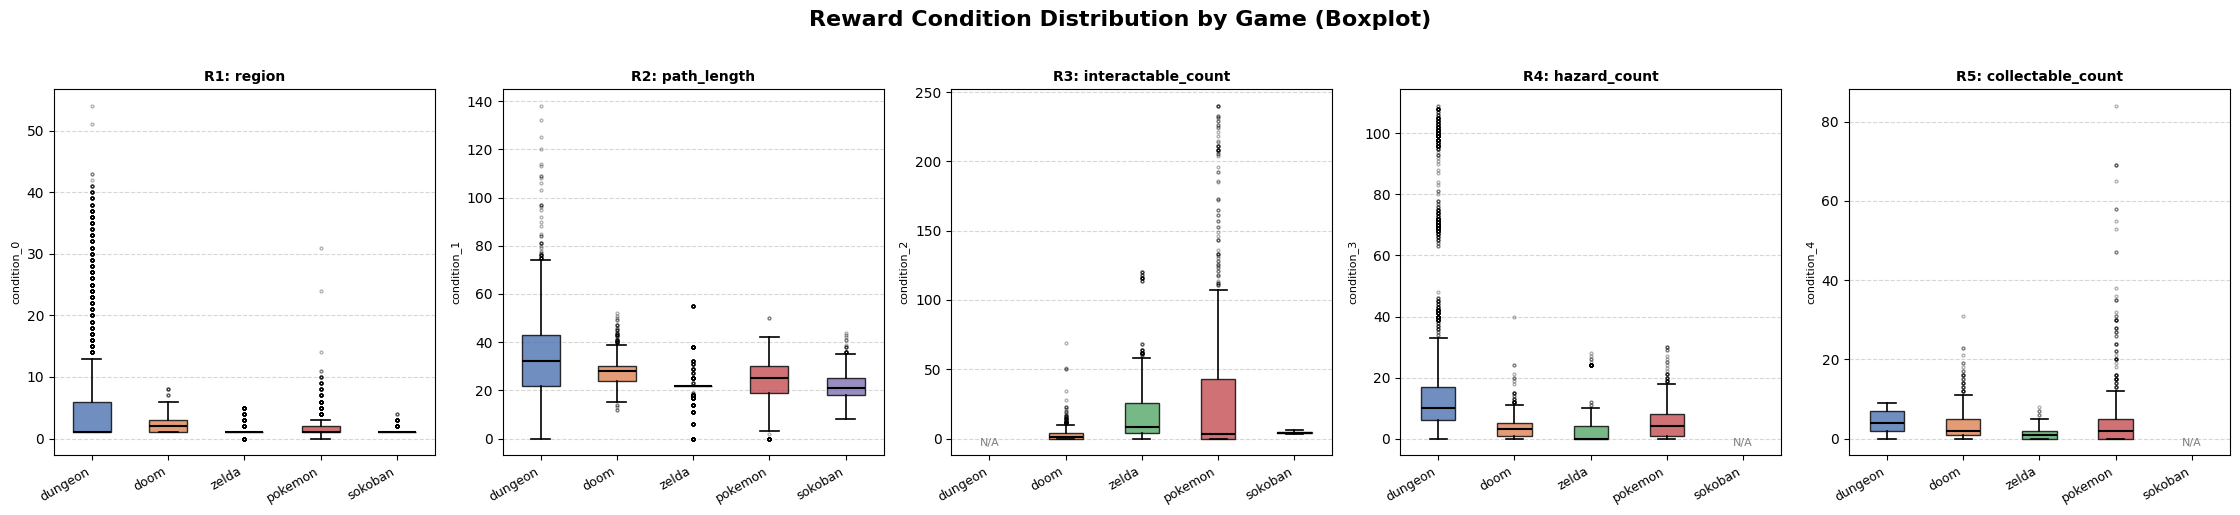

In [4]:
from matplotlib.transforms import blended_transform_factory

GAME_COLORS = {
    "dungeon": "#4C72B0",
    "doom":    "#DD8452",
    "zelda":   "#55A868",
    "pokemon": "#C44E52",
    "sokoban": "#8172B2",
}

def _is_empty(vals):
    """데이터 없음 또는 모두 0인 경우 True."""
    return len(vals) == 0 or (vals == 0).all()

n_rewards = len(REWARDS)
fig, axes = plt.subplots(1, n_rewards, figsize=(4.5 * n_rewards, 5))
fig.suptitle("Reward Condition Distribution by Game (Boxplot)", fontsize=16, fontweight="bold", y=1.02)

for ax, (r_enum, feat, cond_col) in zip(axes, REWARDS):
    sub = all_df[all_df["feature_name"] == feat]

    valid_positions, valid_data, valid_colors = [], [], []
    na_positions = []

    for idx, game in enumerate(GAMES, start=1):
        vals = pd.to_numeric(
            sub[sub["game"] == game][cond_col], errors="coerce"
        ).dropna().values
        if _is_empty(vals):
            na_positions.append(idx)
        else:
            valid_positions.append(idx)
            valid_data.append(vals)
            valid_colors.append(GAME_COLORS[game])

    if valid_data:
        bp = ax.boxplot(
            valid_data,
            positions=valid_positions,
            patch_artist=True,
            medianprops=dict(color="black", linewidth=1.5),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
            flierprops=dict(marker="o", markersize=2, alpha=0.3),
        )
        for patch, color in zip(bp["boxes"], valid_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)

    # N/A 텍스트: x는 데이터 좌표, y는 axes 하단 고정
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    for idx in na_positions:
        ax.text(idx, 0.02, "N/A", ha="center", va="bottom",
                transform=trans, color="gray", fontsize=8)

    ax.set_xticks(range(1, len(GAMES) + 1))
    ax.set_xticklabels(GAMES, rotation=30, ha="right", fontsize=9)
    ax.set_xlim(0.5, len(GAMES) + 0.5)
    ax.set_title(f"R{r_enum}: {feat}", fontsize=10, fontweight="bold")
    ax.set_ylabel(cond_col, fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
#plt.savefig("boxplot_rewards.png", dpi=150, bbox_inches="tight")
plt.show()

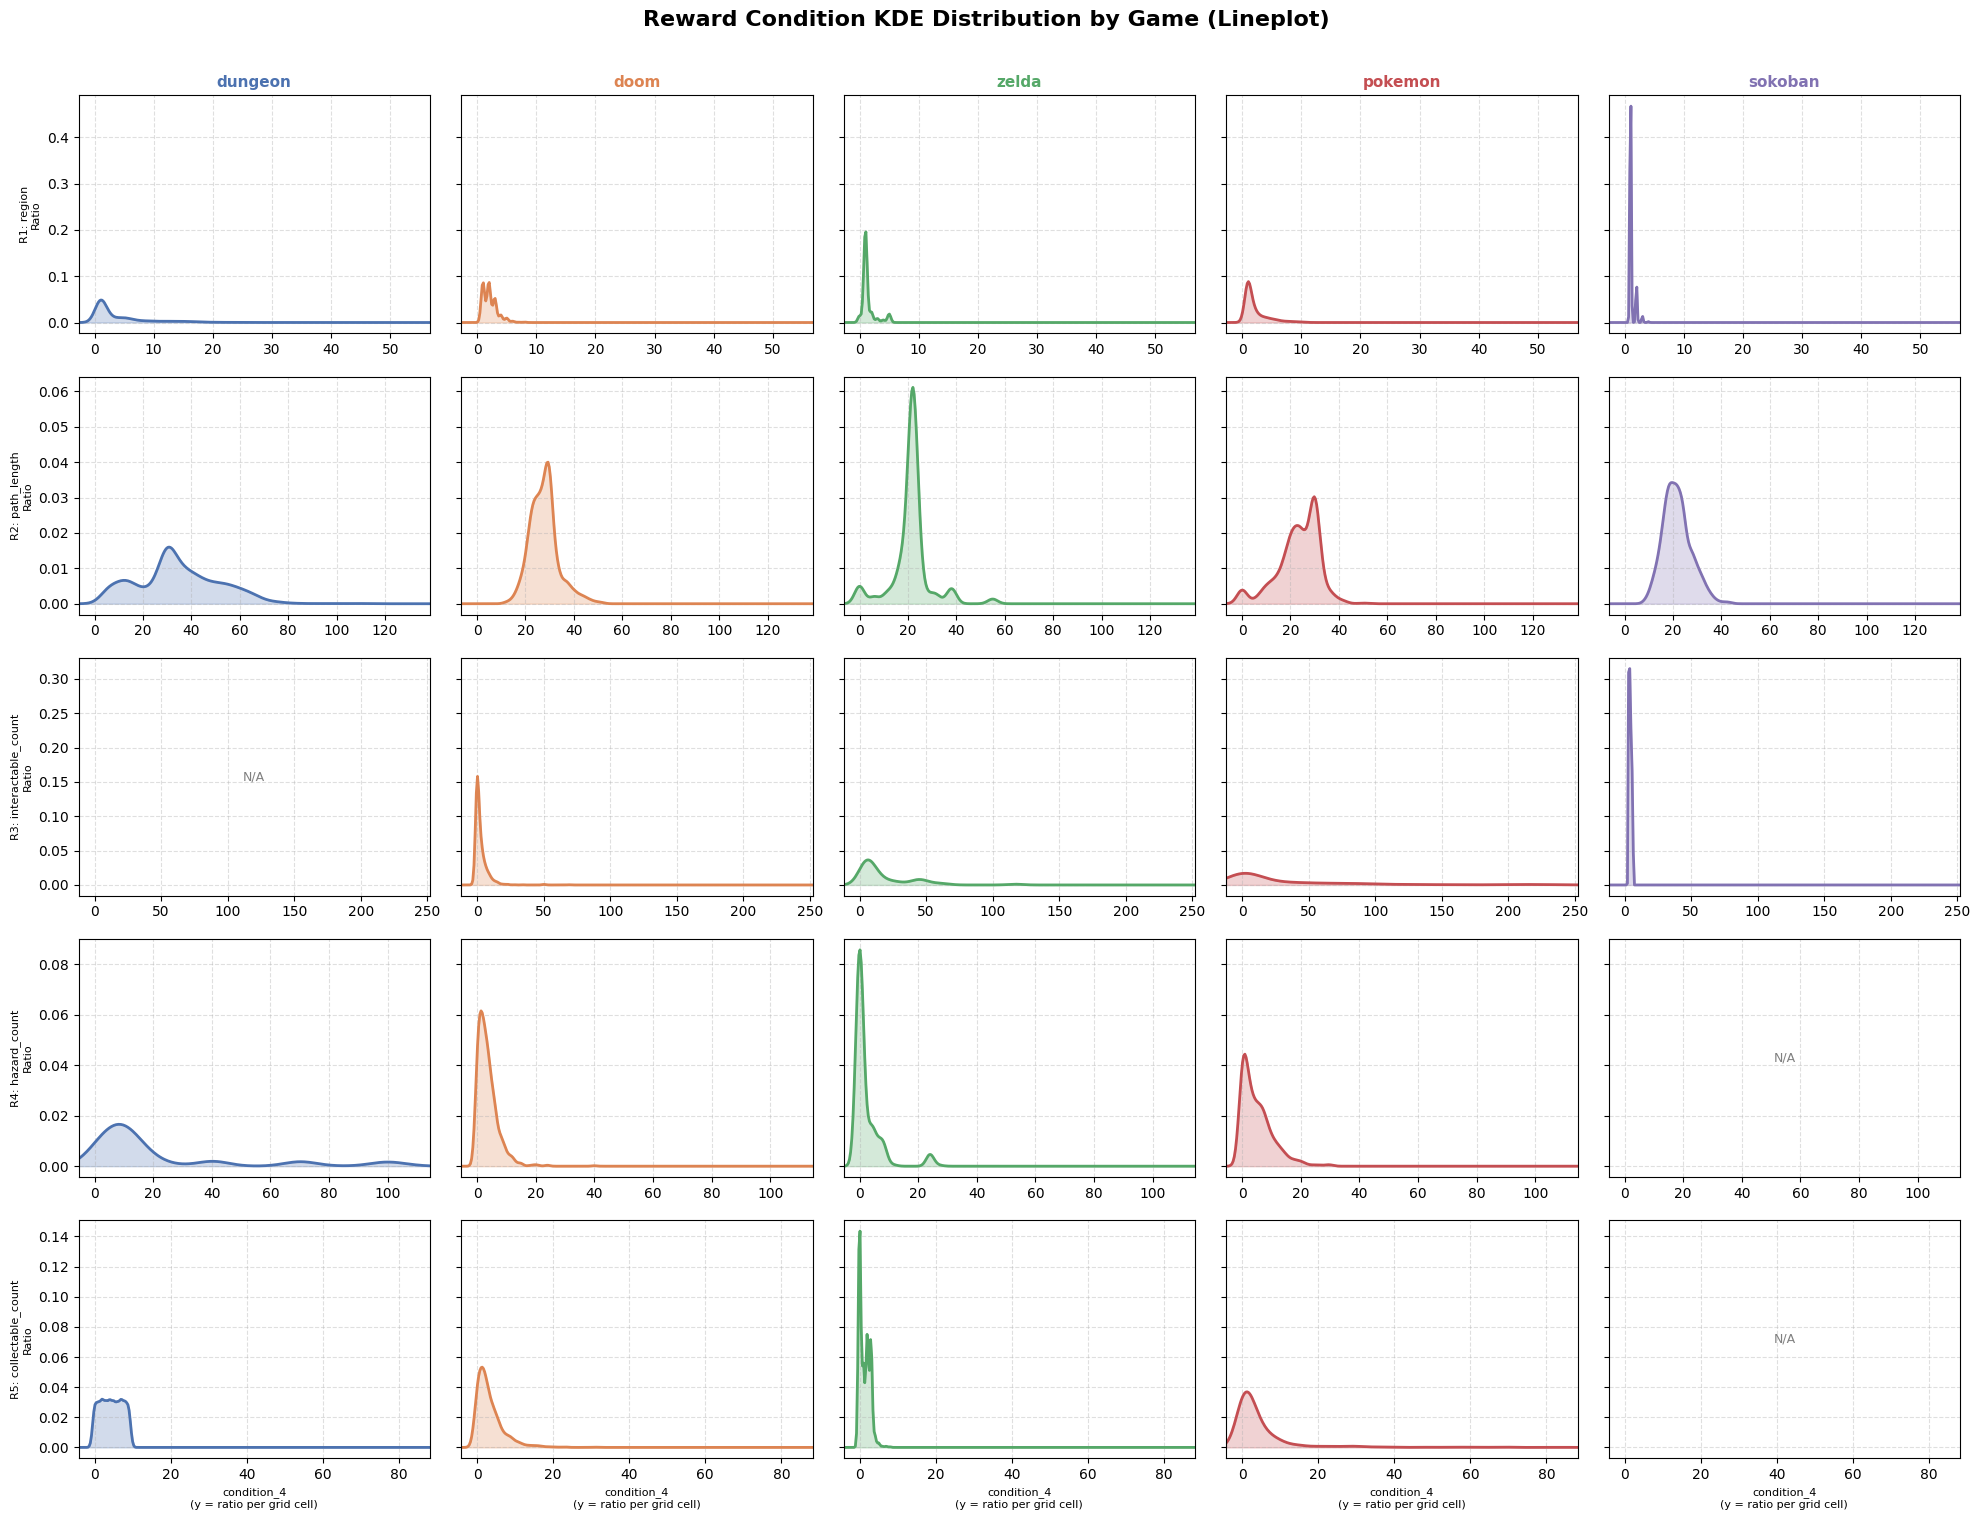

In [12]:
from scipy.stats import gaussian_kde

n_games   = len(GAMES)
n_rewards = len(REWARDS)

fig, axes = plt.subplots(
    n_rewards, n_games,
    figsize=(4 * n_games, 3.0 * n_rewards),
    sharey="row",
)
fig.suptitle("Reward Condition KDE Distribution by Game (Lineplot)", fontsize=16, fontweight="bold", y=1.01)

def _is_empty(vals):
    """데이터 없음 또는 모두 0인 경우 True."""
    return len(vals) == 0 or (vals == 0).all()

for row_i, (r_enum, feat, cond_col) in enumerate(REWARDS):
    sub = all_df[all_df["feature_name"] == feat]

    # N/A가 아닌 게임들의 값(0 포함)으로 x 범위 계산
    valid_vals = []
    for game in GAMES:
        v = pd.to_numeric(sub[sub["game"] == game][cond_col], errors="coerce").dropna().values
        if not _is_empty(v):
            valid_vals.append(v)

    if not valid_vals:
        for col_j in range(n_games):
            axes[row_i, col_j].axis("off")
        continue

    combined = np.concatenate(valid_vals)
    x_min, x_max = combined.min(), combined.max()
    x_pad = (x_max - x_min) * 0.05 if x_max > x_min else 1.0
    x_grid = np.linspace(x_min - x_pad, x_max + x_pad, 300)
    dx = x_grid[1] - x_grid[0]  # density → ratio 변환용

    for col_j, game in enumerate(GAMES):
        ax = axes[row_i, col_j]
        vals = pd.to_numeric(
            sub[sub["game"] == game][cond_col], errors="coerce"
        ).dropna().values

        if _is_empty(vals):
            ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                    transform=ax.transAxes, color="gray", fontsize=9)
            ax.set_xlim(x_min - x_pad, x_max + x_pad)
        elif vals.std() > 0:
            kde = gaussian_kde(vals, bw_method="scott")
            y = kde(x_grid) * dx  # density * dx = 각 grid cell 범위의 데이터 비율
            ax.plot(x_grid, y, color=GAME_COLORS[game], linewidth=2)
            ax.fill_between(x_grid, y, alpha=0.25, color=GAME_COLORS[game])
            ax.set_xlim(x_min - x_pad, x_max + x_pad)
        else:
            ax.axvline(vals.mean(), color=GAME_COLORS[game], linewidth=2)
            ax.set_xlim(x_min - x_pad, x_max + x_pad)

        ax.grid(axis="both", linestyle="--", alpha=0.4)
        if col_j == 0:
            ax.set_ylabel(f"R{r_enum}: {feat}\nRatio", fontsize=8)
        if row_i == 0:
            ax.set_title(game, fontsize=11, fontweight="bold", color=GAME_COLORS[game])
        if row_i == n_rewards - 1:
            ax.set_xlabel(f"{cond_col}\n(y = ratio per grid cell)", fontsize=8)

plt.tight_layout()
#plt.savefig("lineplot_rewards_kde.png", dpi=150, bbox_inches="tight")
plt.show()

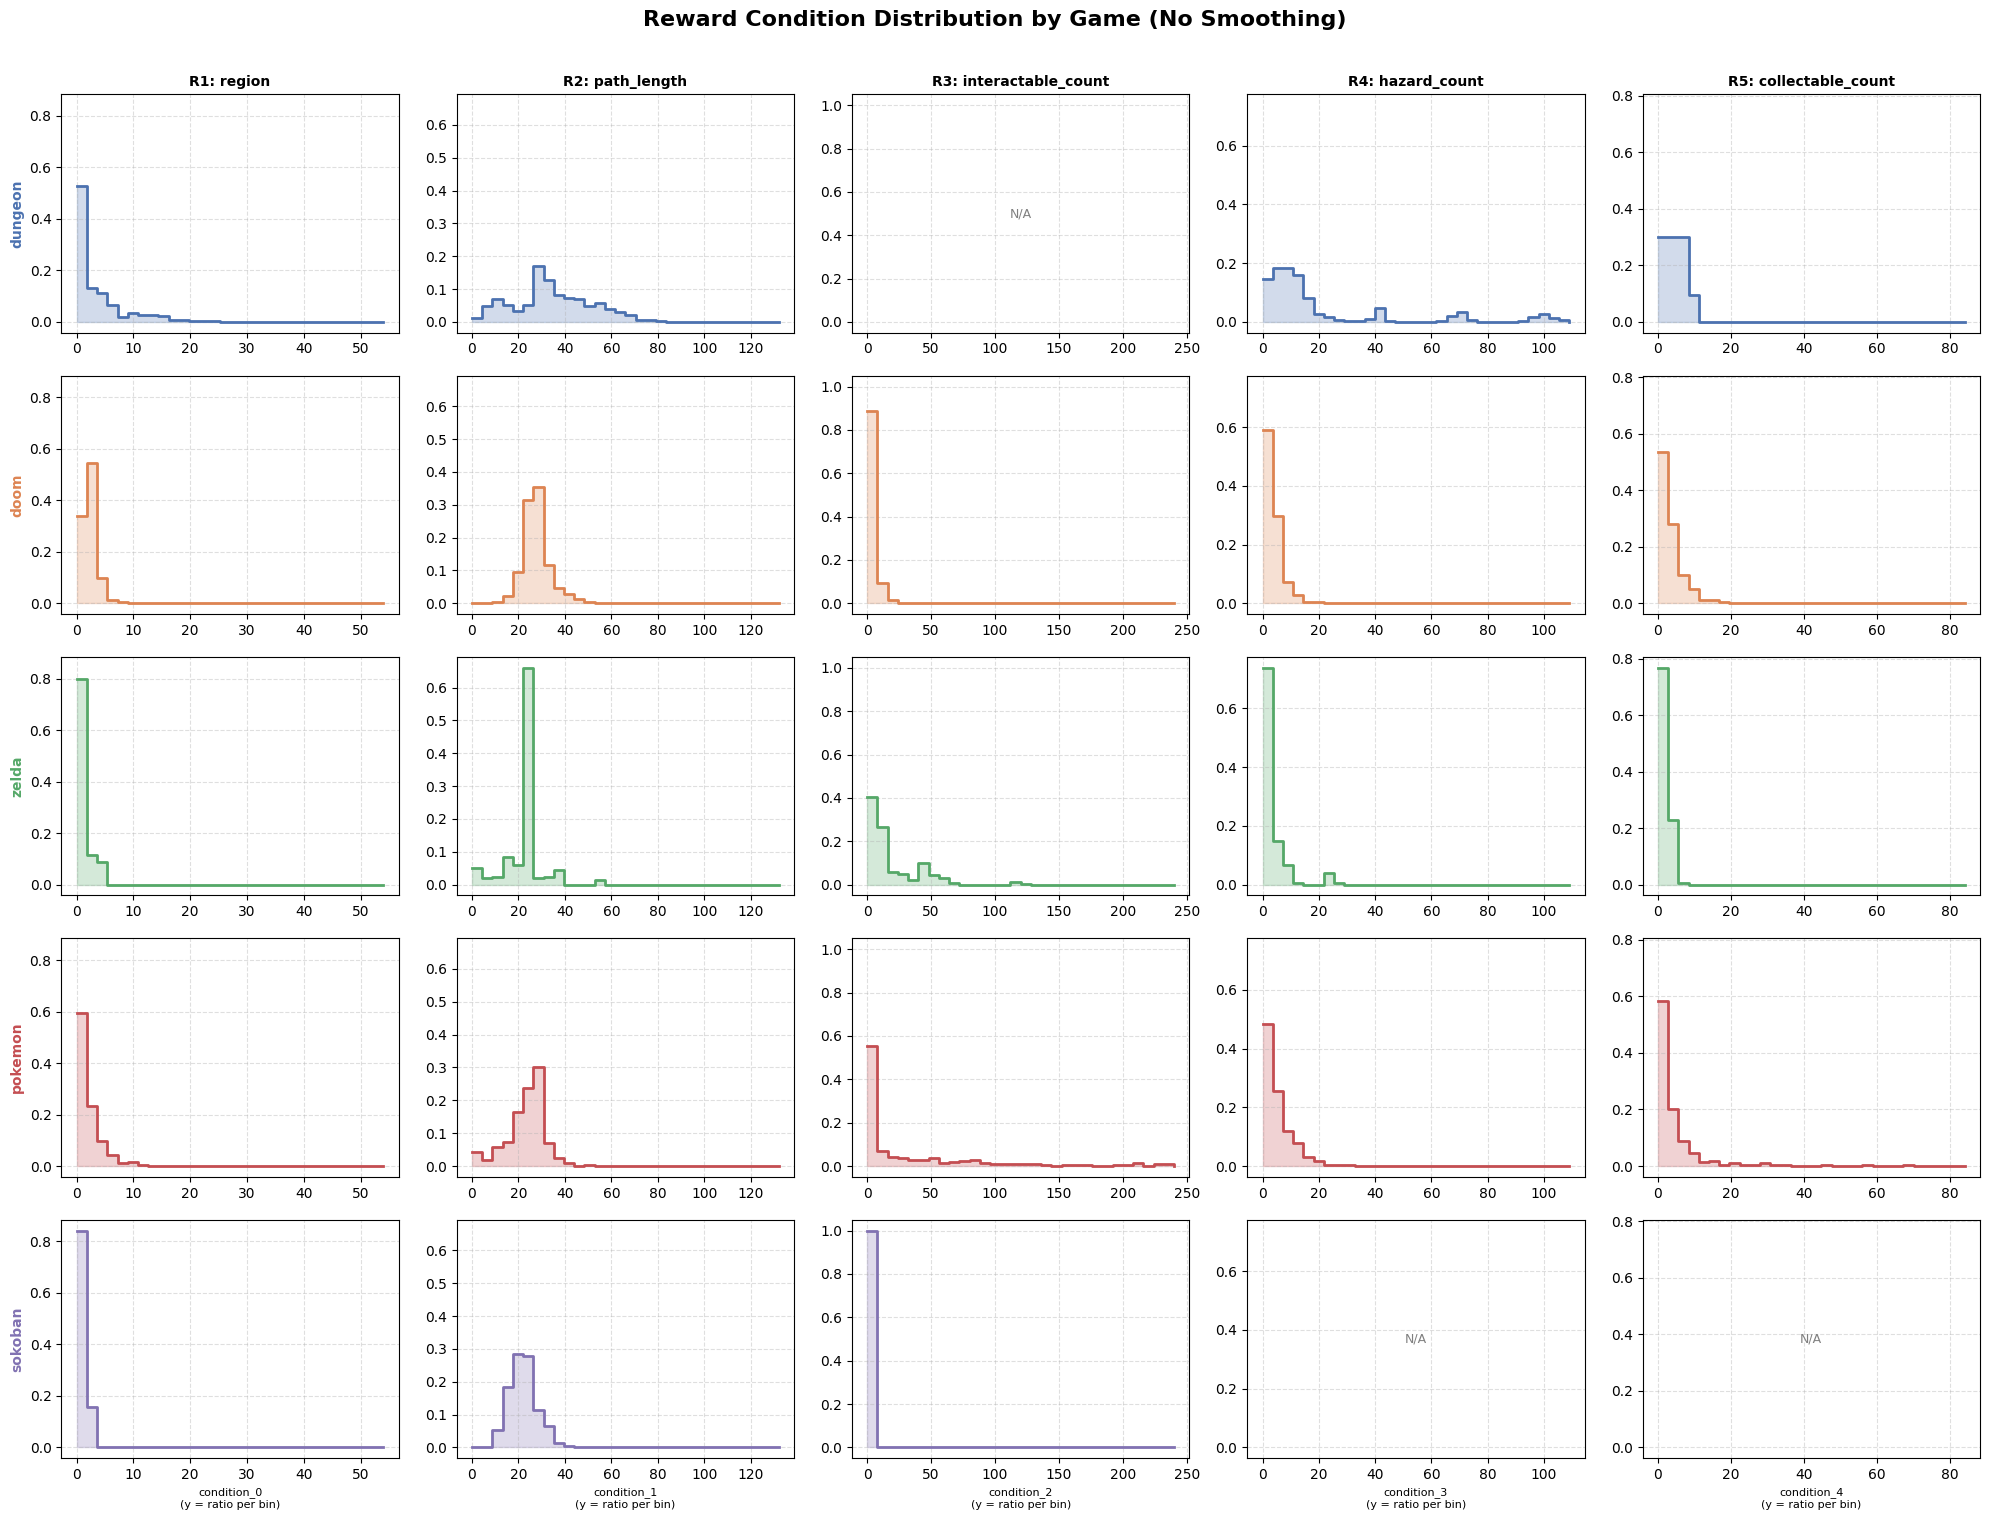

In [13]:
# Lineplot (smoothing 없음) — 행=game, 열=reward, 같은 reward(열)는 y-scale 통일
n_games   = len(GAMES)
n_rewards = len(REWARDS)

fig, axes = plt.subplots(
    n_games, n_rewards,
    figsize=(4 * n_rewards, 3.0 * n_games),
    sharey="col",
)
fig.suptitle("Reward Condition Distribution by Game (No Smoothing)", fontsize=16, fontweight="bold", y=1.01)

N_BINS = 30

def _is_empty(vals):
    """데이터 없음 또는 모두 0인 경우 True."""
    return len(vals) == 0 or (vals == 0).all()

# reward별 x 범위: N/A가 아닌 게임들의 값(0 포함)으로 계산
reward_ranges = {}
for r_enum, feat, cond_col in REWARDS:
    sub = all_df[all_df["feature_name"] == feat]
    valid_vals = []
    for game in GAMES:
        v = pd.to_numeric(sub[sub["game"] == game][cond_col], errors="coerce").dropna().values
        if not _is_empty(v):
            valid_vals.append(v)
    if valid_vals:
        combined = np.concatenate(valid_vals)
        vmin, vmax = combined.min(), combined.max()
        reward_ranges[feat] = (vmin, vmax) if vmax > vmin else (vmin - 1, vmax + 1)
    else:
        reward_ranges[feat] = (0.0, 1.0)

for col_j, (r_enum, feat, cond_col) in enumerate(REWARDS):
    x_min, x_max = reward_ranges[feat]
    x_pad = (x_max - x_min) * 0.05 if x_max > x_min else 1.0
    bins  = np.linspace(x_min, x_max, N_BINS + 1)

    sub = all_df[all_df["feature_name"] == feat]

    for row_i, game in enumerate(GAMES):
        ax = axes[row_i, col_j]
        vals = pd.to_numeric(
            sub[sub["game"] == game][cond_col], errors="coerce"
        ).dropna().values

        if _is_empty(vals):
            ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                    transform=ax.transAxes, color="gray", fontsize=9)
            ax.set_xlim(x_min - x_pad, x_max + x_pad)
        else:
            counts, edges = np.histogram(vals, bins=bins, density=False)
            ratio = counts / len(vals)  # 전체 데이터 중 각 bin의 비율 (0값 포함)
            x_step = np.append(edges[:-1], edges[-1])
            y_step = np.append(ratio, 0)
            ax.step(x_step, y_step, where="post",
                    color=GAME_COLORS[game], linewidth=2)
            ax.fill_between(x_step, y_step, step="post",
                            alpha=0.25, color=GAME_COLORS[game])
            ax.set_xlim(x_min - x_pad, x_max + x_pad)

        ax.grid(axis="both", linestyle="--", alpha=0.4)
        if col_j == 0:
            ax.set_ylabel(game, fontsize=10, fontweight="bold", color=GAME_COLORS[game])
        if row_i == 0:
            ax.set_title(f"R{r_enum}: {feat}", fontsize=10, fontweight="bold")
        if row_i == n_games - 1:
            ax.set_xlabel(f"{cond_col}\n(y = ratio per bin)", fontsize=8)

plt.tight_layout()
plt.show()

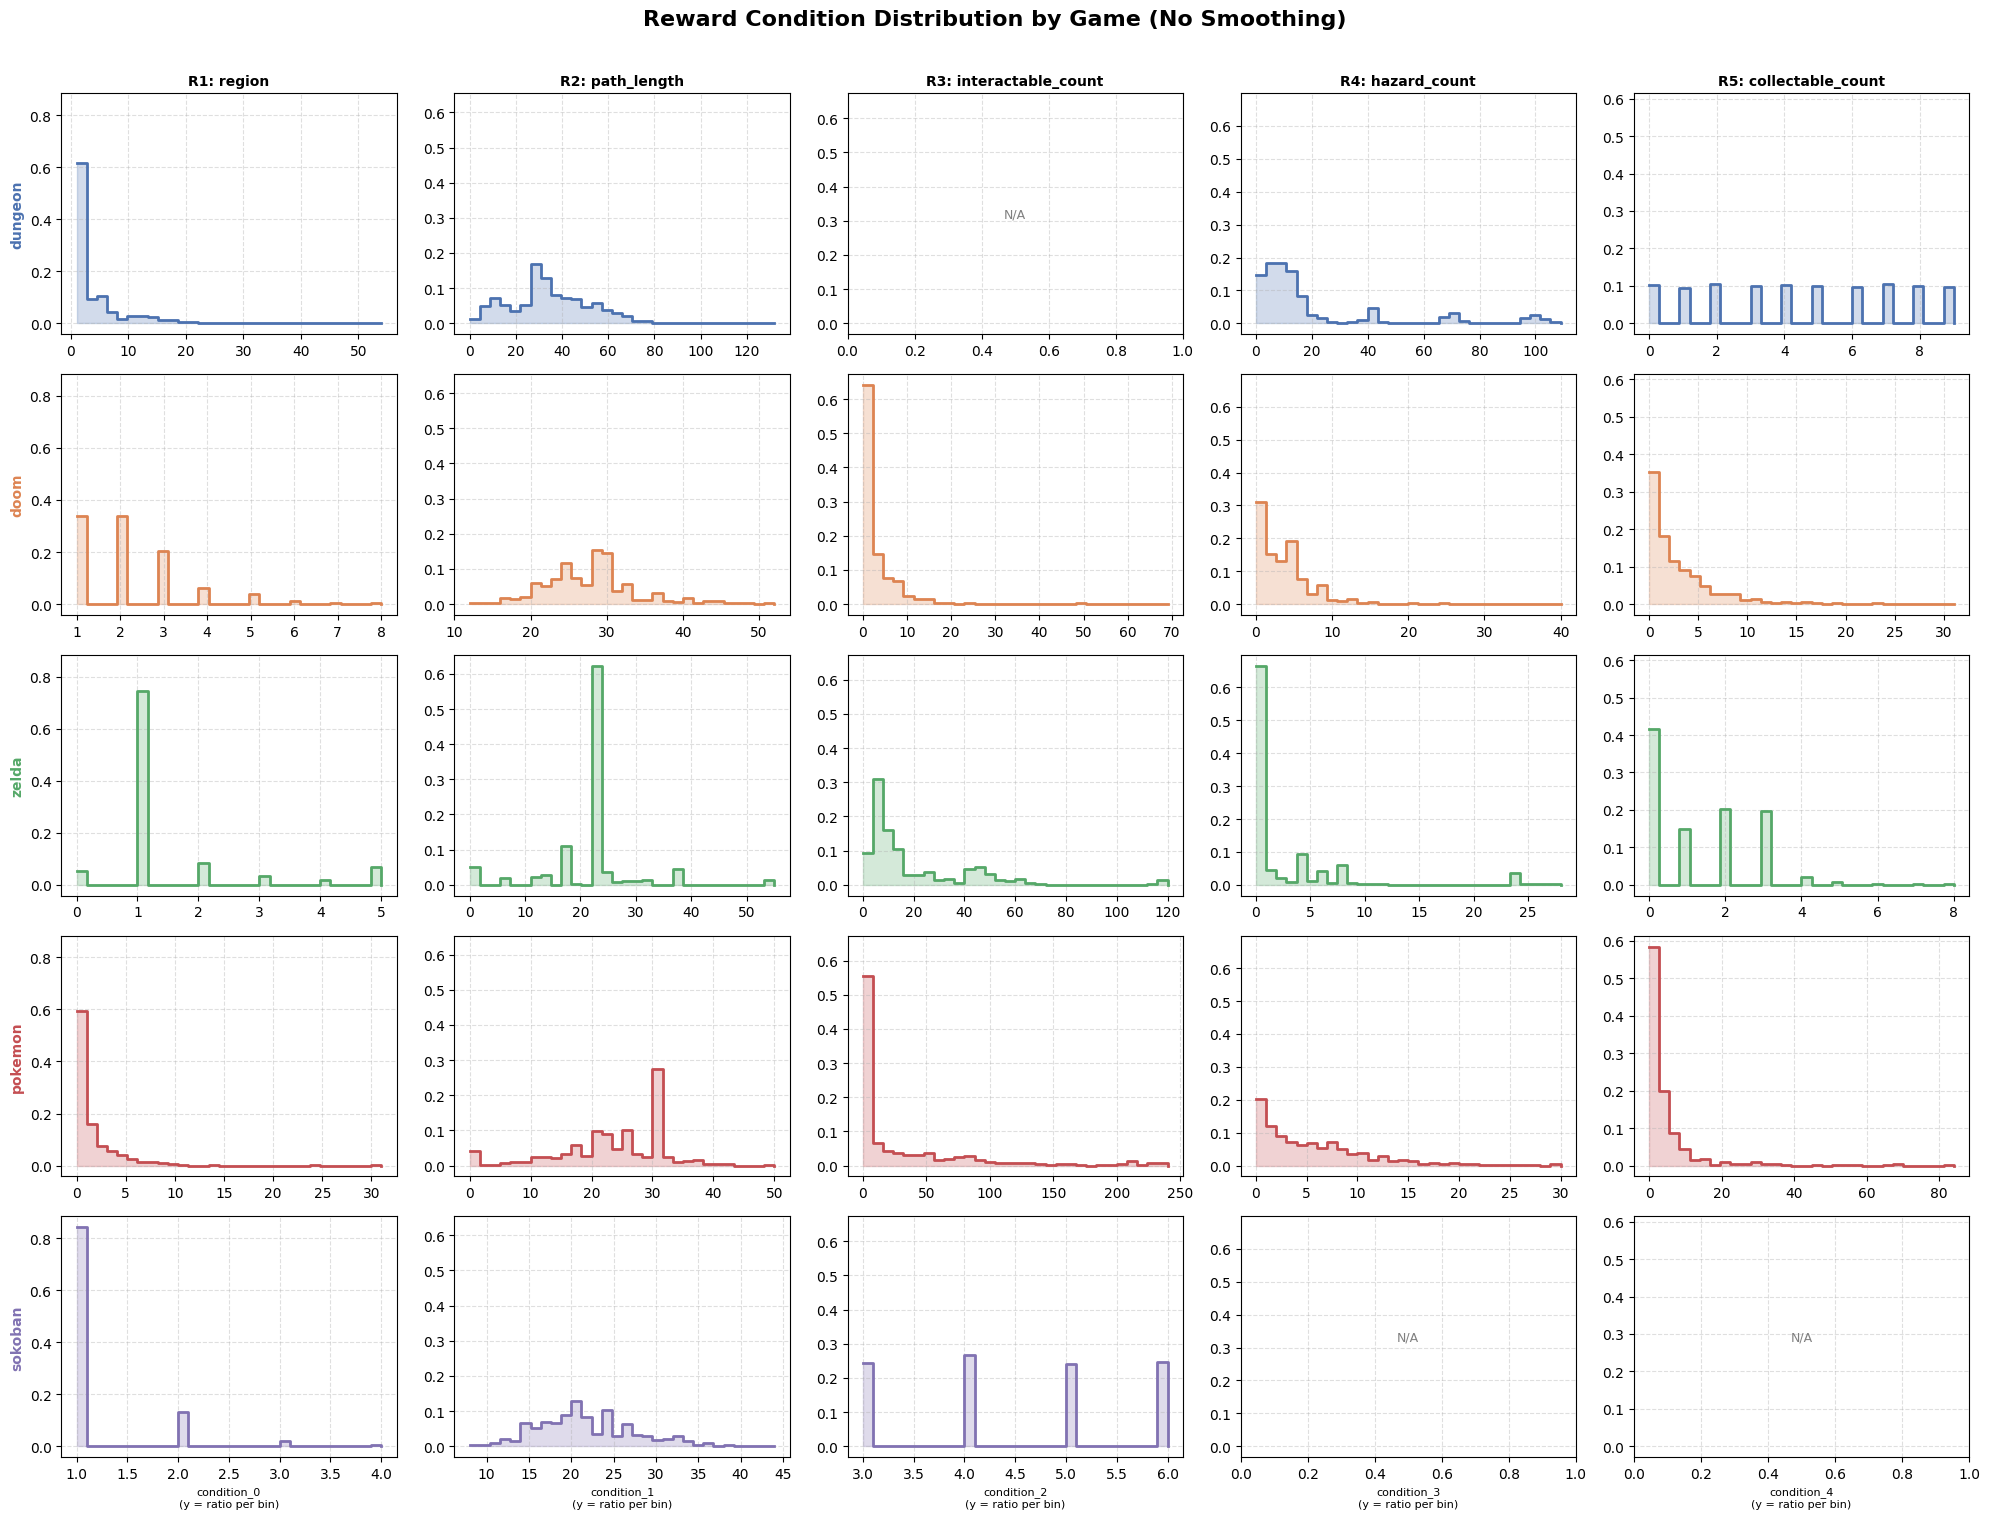

In [14]:
# Lineplot (smoothing 없음) — 행=game, 열=reward, 같은 reward(열)는 y-scale 통일
# xlim 정규화 없음: 각 게임 subplot이 자기 데이터 범위에 맞게 자동 스케일
n_games   = len(GAMES)
n_rewards = len(REWARDS)

fig, axes = plt.subplots(
    n_games, n_rewards,
    figsize=(4 * n_rewards, 3.0 * n_games),
    sharey="col",
)
fig.suptitle("Reward Condition Distribution by Game (No Smoothing)", fontsize=16, fontweight="bold", y=1.01)

N_BINS = 30

def _is_empty(vals):
    """데이터 없음 또는 모두 0인 경우 True."""
    return len(vals) == 0 or (vals == 0).all()

for col_j, (r_enum, feat, cond_col) in enumerate(REWARDS):
    sub = all_df[all_df["feature_name"] == feat]

    for row_i, game in enumerate(GAMES):
        ax = axes[row_i, col_j]
        vals = pd.to_numeric(
            sub[sub["game"] == game][cond_col], errors="coerce"
        ).dropna().values

        if _is_empty(vals):
            ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                    transform=ax.transAxes, color="gray", fontsize=9)
        else:
            v_min, v_max = vals.min(), vals.max()
            bins = (np.linspace(v_min, v_max, N_BINS + 1)
                    if v_max > v_min else np.array([v_min - 0.5, v_max + 0.5]))
            counts, edges = np.histogram(vals, bins=bins, density=False)
            ratio = counts / len(vals)  # 전체 데이터 중 각 bin의 비율
            x_step = np.append(edges[:-1], edges[-1])
            y_step = np.append(ratio, 0)
            ax.step(x_step, y_step, where="post",
                    color=GAME_COLORS[game], linewidth=2)
            ax.fill_between(x_step, y_step, step="post",
                            alpha=0.25, color=GAME_COLORS[game])

        ax.grid(axis="both", linestyle="--", alpha=0.4)
        if col_j == 0:
            ax.set_ylabel(game, fontsize=10, fontweight="bold", color=GAME_COLORS[game])
        if row_i == 0:
            ax.set_title(f"R{r_enum}: {feat}", fontsize=10, fontweight="bold")
        if row_i == n_games - 1:
            ax.set_xlabel(f"{cond_col}\n(y = ratio per bin)", fontsize=8)

plt.tight_layout()
plt.show()

## Threshold Analysis — 게임/enum별 25/50/75% 분위수 기반 구간 비율

In [18]:
import math

def to_half_threshold(q_val):
    """분위수 값을 n.5 경계로 변환.
    정수 기반 데이터에서 특정 값이 두 조건에 걸치지 않도록
    floor(q) + 0.5 로 설정한다.
    """
    return math.floor(q_val) + 0.5


def compute_thresholds_and_ratios(vals):
    """vals에 대해 q25/q50/q75 → n.5 경계 계산 후 각 구간 비율 반환.

    Returns
    -------
    thresholds : list[float]  — 중복 제거된 실제 경계값 (1~3개)
    ratios     : list[float]  — 각 구간의 데이터 비율 (합 = 1.0)
    labels     : list[str]    — 구간 레이블
    """
    q25 = np.percentile(vals, 25)
    q50 = np.percentile(vals, 50)
    q75 = np.percentile(vals, 75)

    t25 = to_half_threshold(q25)
    t50 = to_half_threshold(q50)
    t75 = to_half_threshold(q75)

    # 중복 제거 (같은 n.5 로 몰릴 경우)
    raw = [t25, t50, t75]
    thresholds = sorted(set(raw))

    # 구간 비율 계산
    edges = [-np.inf] + thresholds + [np.inf]
    ratios = []
    labels = []
    for i in range(len(edges) - 1):
        lo, hi = edges[i], edges[i + 1]
        mask = (vals > lo) & (vals <= hi)
        ratios.append(mask.sum() / len(vals))
        lo_str = f"{lo:.1f}" if lo != -np.inf else "-∞"
        hi_str = f"{hi:.1f}" if hi != np.inf else "+∞"
        labels.append(f"({lo_str}, {hi_str}]")

    return thresholds, ratios, labels, (q25, q50, q75)


# ── 결과 수집 ──────────────────────────────────────────────────────────────────
rows = []

for game in GAMES:
    for r_enum, feat, cond_col in REWARDS:
        sub = all_df[(all_df["game"] == game) & (all_df["feature_name"] == feat)]
        vals = pd.to_numeric(sub[cond_col], errors="coerce").dropna().values

        if _is_empty(vals):
            rows.append({
                "game": game, "feature": feat,
                "q25_raw": None, "q50_raw": None, "q75_raw": None,
                "thresholds": "N/A", "ratios": "N/A",
            })
            continue

        thresholds, ratios, labels, (q25, q50, q75) = compute_thresholds_and_ratios(vals)

        rows.append({
            "game": game,
            "feature": feat,
            "q25_raw": round(q25, 3),
            "q50_raw": round(q50, 3),
            "q75_raw": round(q75, 3),
            "thresholds": str(thresholds),
            **{f"ratio_{lbl}": round(r, 4) for lbl, r in zip(labels, ratios)},
        })

result_df = pd.DataFrame(rows)
print(result_df.to_string(index=False))


   game            feature  q25_raw  q50_raw  q75_raw         thresholds  ratio_(-∞, 1.5]  ratio_(1.5, 5.5]  ratio_(5.5, +∞]  ratio_(-∞, 25.5]  ratio_(25.5, 33.5]  ratio_(33.5, 45.5]  ratio_(45.5, +∞] ratios  ratio_(-∞, 5.5]  ratio_(5.5, 10.5]  ratio_(10.5, 18.5]  ratio_(18.5, +∞]  ratio_(-∞, 2.5]  ratio_(2.5, 4.5]  ratio_(4.5, 7.5]  ratio_(7.5, +∞]  ratio_(1.5, 2.5]  ratio_(2.5, 3.5]  ratio_(3.5, +∞]  ratio_(-∞, 24.5]  ratio_(24.5, 28.5]  ratio_(28.5, 30.5]  ratio_(30.5, +∞]  ratio_(-∞, 0.5]  ratio_(0.5, 1.5]  ratio_(1.5, 4.5]  ratio_(4.5, +∞]  ratio_(1.5, 3.5]  ratio_(3.5, 5.5]  ratio_(2.5, 5.5]  ratio_(1.5, +∞]  ratio_(-∞, 22.5]  ratio_(22.5, +∞]  ratio_(-∞, 4.5]  ratio_(4.5, 8.5]  ratio_(8.5, 26.5]  ratio_(26.5, +∞]  ratio_(0.5, 4.5]  ratio_(2.5, +∞]  ratio_(-∞, 19.5]  ratio_(19.5, 25.5]  ratio_(25.5, 30.5]  ratio_(0.5, 3.5]  ratio_(3.5, 43.5]  ratio_(43.5, +∞]  ratio_(8.5, +∞]  ratio_(0.5, 2.5]  ratio_(-∞, 18.5]  ratio_(18.5, 21.5]  ratio_(21.5, 25.5]  ratio_(25.5, +∞]  ratio_(4.5

값## Custom Threshold 조정 — 아래 셀의 값을 직접 수정 후 다음 셀 실행

In [16]:
# ── CUSTOM_THRESHOLDS: (game_feature) → threshold 리스트 ─────────────────────
# 값을 직접 수정한 뒤 다음 셀을 실행하면 표가 업데이트됩니다.
# None = 해당 (game, feature) 조합이 없음 (N/A)
# threshold 개수: 1개→2구간, 2개→3구간, 3개→4구간
# instruction 달 때는 이걸 사용해야 한다

CUSTOM_THRESHOLDS = {
    "dungeon_region":             [1.5, 4.5, 10.5],
    "dungeon_path_length":        [23.5, 32.5, 46.5],
    "dungeon_interactable_count": None,
    "dungeon_hazard_count":       [5.5, 10.5, 18.5],
    "dungeon_collectable_count":  [1.5, 4.5, 7.5],

    "doom_region":                [1.5, 2.5, 3.5],
    "doom_path_length":           [23.5, 27.5, 30.5],
    "doom_interactable_count":    [0.5, 3.5, 6.5],
    "doom_hazard_count":          [1.5, 3.5, 5.5],
    "doom_collectable_count":     [1.5, 2.5, 5.5],

    "zelda_region":               [1.5, 2.5, 4.5],
    "zelda_path_length":          [16.5, 21.5, 22.5],
    "zelda_interactable_count":   [4.5, 8.5, 26.5],
    "zelda_hazard_count":         [0.5, 4.5, 8.5],
    "zelda_collectable_count":    [0.5, 1.5, 2.5],

    "pokemon_region":             [1.5, 2.5, 4.5],
    "pokemon_path_length":        [18.5, 24.5, 30.5],
    "pokemon_interactable_count": [0.5, 20.5, 60.5],
    "pokemon_hazard_count":       [1.5, 4.5, 8.5],
    "pokemon_collectable_count":  [0.5, 2.5, 6.5],

    "sokoban_region":             [1.5, 2.5, 3.5],
    "sokoban_path_length":        [17.5, 21.5, 25.5],
    "sokoban_interactable_count": [3.5, 4.5, 5.5],
    "sokoban_hazard_count":       None,
    "sokoban_collectable_count":  None,
}


In [17]:
# ── Custom Threshold 기반 표 ──────────────────────────────────────────────────
# 위 셀에서 CUSTOM_THRESHOLDS를 수정한 뒤 이 셀을 재실행하면 표가 업데이트됩니다.

def compute_ratios_from_thresholds(vals, thresholds):
    """주어진 threshold 리스트로 각 구간의 비율과 레이블 반환."""
    edges = [-np.inf] + sorted(thresholds) + [np.inf]
    ratios, labels = [], []
    for i in range(len(edges) - 1):
        lo, hi = edges[i], edges[i + 1]
        mask = (vals > lo) & (vals <= hi)
        ratios.append(mask.sum() / len(vals))

        # n.5 threshold 기준: 구간 내 정수 범위 계산
        # lo=2.5 → 첫 정수 = 3 (int(lo+0.51))
        # hi=5.5 → 마지막 정수 = 5 (int(hi-0.49))
        lo_int = int(lo + 0.51) if lo != -np.inf else None
        hi_int = int(hi - 0.49) if hi != np.inf else None

        if lo_int is None and hi_int is None:
            lbl = "all"
        elif lo_int is None:
            lbl = f"~{hi_int}"
        elif hi_int is None:
            lbl = f"{lo_int}~"
        elif lo_int == hi_int:
            lbl = f"{lo_int}"
        else:
            lbl = f"{lo_int}~{hi_int}"
        labels.append(lbl)

    return ratios, labels


custom_rows = []

for game in GAMES:
    for r_enum, feat, cond_col in REWARDS:
        sub = all_df[(all_df["game"] == game) & (all_df["feature_name"] == feat)]
        vals = pd.to_numeric(sub[cond_col], errors="coerce").dropna().values
        key = f"{game}_{feat}"
        thresholds = CUSTOM_THRESHOLDS.get(key)

        if _is_empty(vals) or thresholds is None:
            custom_rows.append({
                "Game": game, "Feature": feat,
                "Thresholds": "N/A",
                "Bin1 Range": "-", "Bin1 %": "-",
                "Bin2 Range": "-", "Bin2 %": "-",
                "Bin3 Range": "-", "Bin3 %": "-",
                "Bin4 Range": "-", "Bin4 %": "-",
            })
            continue

        ratios, labels = compute_ratios_from_thresholds(vals, thresholds)

        bins_info = list(zip(labels, ratios))
        while len(bins_info) < 4:
            bins_info.append(("-", None))

        row = {
            "Game": game,
            "Feature": feat,
            "Thresholds": str(sorted(thresholds)),
        }
        for i, (lbl, r) in enumerate(bins_info[:4], start=1):
            row[f"Bin{i} Range"] = lbl
            row[f"Bin{i} %"] = f"{r*100:.1f}%" if r is not None else "-"

        custom_rows.append(row)

custom_tbl = pd.DataFrame(custom_rows)

display(custom_tbl.style
    .set_properties(**{"text-align": "center", "white-space": "nowrap"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center"), ("background-color", "#ddeeff")]},
        {"selector": "tr:hover", "props": [("background-color", "#f5f5ff")]},
    ])
    .hide(axis="index")
)


Game,Feature,Thresholds,Bin1 Range,Bin1 %,Bin2 Range,Bin2 %,Bin3 Range,Bin3 %,Bin4 Range,Bin4 %
dungeon,region,"[1.5, 4.5, 10.5]",~1,52.7%,2~4,18.2%,5~10,18.1%,11~,11.0%
dungeon,path_length,"[23.5, 32.5, 46.5]",~23,23.7%,24~32,25.4%,33~46,27.3%,47~,23.6%
dungeon,interactable_count,N/A,-,-,-,-,-,-,-,-
dungeon,hazard_count,"[5.5, 10.5, 18.5]",~5,25.2%,6~10,26.3%,11~18,24.2%,19~,24.2%
dungeon,collectable_count,"[1.5, 4.5, 7.5]",~1,19.7%,2~4,30.7%,5~7,30.1%,8~,19.5%
doom,region,"[1.5, 2.5, 3.5]",~1,33.8%,2,34.0%,3,20.4%,4~,11.8%
doom,path_length,"[23.5, 27.5, 30.5]",~23,24.3%,24~27,24.6%,28~30,30.0%,31~,21.1%
doom,interactable_count,"[0.5, 3.5, 6.5]",~0,46.6%,1~3,26.8%,4~6,13.0%,7~,13.6%
doom,hazard_count,"[1.5, 3.5, 5.5]",~1,30.9%,2~3,28.2%,4~5,19.1%,6~,21.8%
doom,collectable_count,"[1.5, 2.5, 5.5]",~1,35.3%,2,18.2%,3~5,28.2%,6~,18.3%
